<a href="https://colab.research.google.com/github/Deivs117/ProyectoSeriesTiempo/blob/main/KTALYNA_DAVID_TF_serie_tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pronóstico de Consumo Eléctrico con Deep Learning
## Dataset: Individual Household Electric Power Consumption — UCI ML Repository

---

## 0. Problemática

### Contexto
El consumo eléctrico residencial representa aproximadamente el 27% del
consumo energético total en países desarrollados. Un hogar promedio no
tiene visibilidad sobre su propio patrón de consumo — solo lo descubre
cuando llega la factura mensual. Esto impide tomar decisiones preventivas
como redistribuir el uso de electrodomésticos de alta potencia hacia
horas de tarifa baja.

### Problema
**¿Es posible anticipar el consumo eléctrico de un hogar con una hora
de anticipación, usando únicamente el historial reciente de sus propias
variables eléctricas?**

Sin un sistema de pronóstico:
- El hogar no puede optimizar su consumo en tiempo real.
- La distribuidora eléctrica no puede anticipar picos de demanda
  a nivel de usuario individual.
- No es posible detectar anomalías de consumo de forma automática
  — por ejemplo un electrodoméstico defectuoso que consume de más.

### ¿Por qué es difícil?
El consumo eléctrico es una señal compleja porque combina:
- **Ciclos regulares:** patrones diarios (mañana/noche) y semanales
  (laborable/fin de semana) que se repiten pero no son idénticos.
- **Eventos aleatorios:** encender el horno, una lavadora, el aire
  acondicionado — eventos impredecibles que generan picos abruptos.
- **Múltiples variables correlacionadas:** voltaje, potencia reactiva,
  submedidores — cada una aporta una dimensión distinta del consumo.

---

## 1. Solución propuesta

### Enfoque
Se propone un sistema de pronóstico basado en **Deep Learning sobre
series de tiempo multivariadas**, desplegado en entorno **Cloud**,
que toma las últimas 24 horas de mediciones eléctricas del hogar
y predice el consumo 1 hora hacia el futuro.

### ¿Por qué Deep Learning y no modelos clásicos?
Los modelos clásicos como ARIMA o SARIMA asumen linealidad y requieren
stationariedad estricta. El consumo eléctrico tiene:
- Patrones no lineales (picos abruptos por electrodomésticos).
- Múltiples estacionalidades superpuestas (diaria + semanal).
- Variables exógenas (voltaje, submedidores) que ARIMA no incorpora.

El Deep Learning maneja todo esto de forma nativa.

### Entorno de despliegue: Cloud
El sistema opera en Cloud porque:
- Los modelos (LSTM, Transformer) requieren más memoria de la que
  un dispositivo embebido puede ofrecer económicamente.
- El caso de uso es un **dashboard de monitoreo remoto** con alertas
  de consumo anómalo — una latencia de 500ms–2s es completamente aceptable.
- El reentrenamiento automático es trivial en Cloud: cuando el MAE en
  producción supera **1.2× el MAE de referencia**, el pipeline MLOps
  dispara un nuevo ciclo de entrenamiento.

### Formulación matemática
La serie de consumo se descompone como:

$$x_t = T_t + S_t^{(24)} + S_t^{(168)} + \varepsilon_t$$

Donde:
- $T_t$ = tendencia de largo plazo
- $S_t^{(24)}$ = componente estacional diaria (ciclo de 24h)
- $S_t^{(168)}$ = componente estacional semanal (ciclo de 168h)
- $\varepsilon_t$ = ruido aleatorio no predecible

El modelo aprende a estimar $\hat{x}_{t+1}$ dado:

$$\mathbf{X} = [x_{t-23}, x_{t-22}, \ldots, x_t] \in \mathbb{R}^{24 \times 9}$$

### Justificación de la ventana y el horizonte
- **24h de historia:** cubre exactamente $S_t^{(24)}$ — un ciclo diario
  completo. El modelo puede ubicar la predicción dentro del ciclo circadiano.
- **1h de horizonte:** operacionalmente útil para gestión energética en
  tiempo real. Horizontes mayores aumentan exponencialmente la incertidumbre
  en $\varepsilon_t$.

### Modelos comparados
Se entrenan y comparan cuatro arquitecturas para identificar cuál
captura mejor la estructura temporal del consumo:

| Modelo | Idea central |
|---|---|
| **Baseline** | Repite el último valor conocido — piso mínimo de referencia |
| **Conv1D** | Detecta patrones locales mediante filtros convolucionales |
| **LSTM** | Aprende dependencias de largo plazo mediante memoria recurrente |
| **Transformer** | Pondera cada paso de la ventana mediante atención |

---

### 3. Latencia de inferencia: documentación obligatoria para viabilidad técnica

Aunque para un horizonte de 1 hora la latencia de inferencia en milisegundos **no representa un cuello de botella operativo crítico**, su documentación explícita es **obligatoria** por las siguientes razones de ingeniería de sistemas:

1. **Ciclo de vida del modelo:** la latencia basal en producción establece la línea de referencia (*performance baseline*) para detectar degradación futura causada por **Data Drift** (cambio en la distribución de $x_t$) o **Concept Drift** (cambio en la relación $f: x_t \rightarrow y_{t+h}$). Si la latencia p99 sube un 40% en 6 meses sin cambio de hardware, es señal de que el modelo está siendo forzado a compensar errores de representación con más cómputo (p. ej., mayor profundidad de embedding).
2. **Estrategia de reentrenamiento:** para planificar el ciclo de reentrenamiento continuo (CI/CD de modelos — MLOps), se necesita comparar el tiempo de inferencia antes y después del reentrenamiento para garantizar que la nueva versión es **Pareto-dominante** (mejores métricas estadísticas AND latencia equivalente o inferior).
3. **SLA formal:** un contrato de nivel de servicio para sistemas de monitoreo energético residencial exige que el sistema emita una predicción dentro de un ventana de latencia $L_{SLA}$ acotada, siendo usual $L_{SLA} \leq 100$ ms para Edge y $\leq 50$ ms (p99) para Cloud.

Por lo tanto, se medirá y reportará explícitamente la **latencia de inferencia por muestra** para cada modelo.

---

### 4. Variable categórica `day_type`

Se deriva `day_type` desde la fecha: laborable / sábado / domingo.  
El patrón de consumo varía estructuralmente según el tipo de día — los fines de semana exhiben picos más tardíos y diferentes valles nocturnos, validado empíricamente en el EDA.

- **Variable objetivo:** `Global_active_power` (kW) — potencia activa global del hogar
- **Tipo de problema:** regresión sobre serie de tiempo multivariada
- **Features:** 9 variables (6 numéricas + 3 one-hot de tipo de día)


## 1. Librerías

In [1]:
import os, requests, zipfile, time, warnings
warnings.filterwarnings('ignore')

#import sympy.printing
#import sympy.printing.str

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# statsmodels — pruebas formales de estacionariedad (ADF, KPSS)
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams['figure.figsize'] = (13, 4)
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch:     {torch.__version__}")


Dispositivo: cuda
PyTorch:     2.10.0+cu128


## 2. Carga de datos

El dataset registra el consumo eléctrico de un hogar en Francia, minuto a minuto,
entre 2006 y 2010. Tiene 7 variables numéricas y 2 millones de filas.
Los valores faltantes están marcados con `?`.

In [2]:
url      = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "00235/household_power_consumption.zip")
zip_path = "household_power_consumption.zip"
txt_path = "household_power_consumption.txt"

if not os.path.exists(txt_path):
    print("Descargando...")
    r = requests.get(url, timeout=60)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print("Descarga completa")
else:
    print("Ya existe en disco")

df_raw = pd.read_csv(txt_path, sep=";", na_values="?", low_memory=False)
print(f"Shape: {df_raw.shape}")
print(f"Columnas: {df_raw.columns.tolist()}")
df_raw.head(3)

Descargando...
Descarga completa
Shape: (2075259, 9)
Columnas: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


## 2.1 Descripción de variables

| Variable | Unidad | Descripción |
|---|---|---|
| `Global_active_power` | kW | Potencia activa global consumida por el hogar — **variable objetivo** |
| `Global_reactive_power` | kVAR | Potencia reactiva global |
| `Voltage` | V | Voltaje en la red eléctrica del hogar |
| `Global_intensity` | A | Intensidad de corriente global (P = V×I) |
| `Sub_metering_1` | Wh | Submedidor 1 — cocina (lavavajillas, horno, microondas) |
| `Sub_metering_2` | Wh | Submedidor 2 — lavandería (lavadora, secadora, nevera) |
| `Sub_metering_3` | Wh | Submedidor 3 — climatización (calefacción, aire acondicionado) |

### Variable derivada
| Variable | Tipo | Descripción |
|---|---|---|
| `day_type` | Categórica | Tipo de día derivado de la fecha: **0** = laborable · **1** = sábado · **2** = domingo |

### Notas importantes
- La energía **no medida** por los submedidores corresponde a iluminación,
  televisión y otros electrodomésticos pequeños.
- La resolución original es de **1 minuto** — se submuestreará a **1 hora**.

## 3. Limpieza y preprocesamiento

## 3.1 Inspección de valores faltantes

Antes de decidir qué hacer con los nulos, hay que entender su naturaleza:
¿son errores aleatorios puntuales o bloques continuos del sensor apagado?
Eso cambia completamente la decisión de limpieza.

### 3.2 Valores faltantes
El dataset tiene aprox. 26.000 filas con valores faltantes (1.25% del total).
Estos nulos aparecen en bloques continuos, indican apagones del sensor,
no errores aleatorios. Decisión: **eliminarlos**, porque imputar bloques
de horas enteras introduciría patrones que el modelo aprendería
de forma errónea.

### 3.3 Parseo de fechas y submuestreo
Las columnas `Date` y `Time` se fusionan en un índice datetime.
Luego se submuestrea a **1 hora** usando la media, lo que reduce el dataset
de 2M a 35k filas y suaviza picos momentáneos del sensor.

### 3.3 Variable categórica: day_type
Se crea `day_type` desde la fecha: laborable (0), sábado (1), domingo (2).
El consumo en fin de semana tiene picos más tardíos y valles distintos,
esta variable le da al modelo contexto estructural que las numéricas no tienen.
Se aplica **one-hot encoding** para no introducir orden entre categorías.

### 3.4 Eliminación de Global_intensity
`Global_intensity` tiene correlación 0.99 con `Global_active_power`
porque físicamente P = V × I. Incluirla sería redundante y causaría
multicolinealidad.

                       Nulos  Porcentaje (%)
Date                       0           0.000
Time                       0           0.000
Global_active_power    25979           1.252
Global_reactive_power  25979           1.252
Voltage                25979           1.252
Global_intensity       25979           1.252
Sub_metering_1         25979           1.252
Sub_metering_2         25979           1.252
Sub_metering_3         25979           1.252

Total de bloques con nulos:       71
Bloque más largo:                 7,226 minutos (120.4 horas)
Mediana del tamaño de bloque:     1 minutos


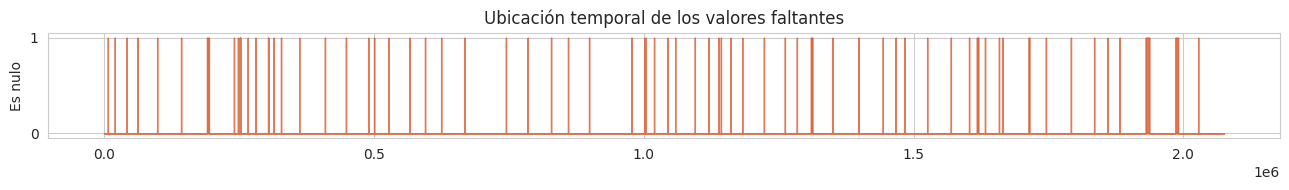

In [3]:
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(3)
print(pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": pct}))

es_nulo = df_raw["Global_active_power"].isnull()

# Identificar bloques consecutivos de nulos
bloques = es_nulo.groupby((es_nulo != es_nulo.shift()).cumsum())
tamanos_bloques = bloques.sum()
bloques_reales  = tamanos_bloques[tamanos_bloques > 0]

print(f"\nTotal de bloques con nulos:       {len(bloques_reales)}")
print(f"Bloque más largo:                 {bloques_reales.max():,} minutos "
      f"({bloques_reales.max()/60:.1f} horas)")
print(f"Mediana del tamaño de bloque:     {bloques_reales.median():.0f} minutos")

# Visualizar dónde están los nulos en el tiempo
fig, ax = plt.subplots(figsize=(13, 2))
ax.fill_between(df_raw.index,
                es_nulo.astype(int),
                color="#D85A30", alpha=0.8)
ax.set_title("Ubicación temporal de los valores faltantes")
ax.set_ylabel("Es nulo")
ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

In [4]:
# Parseo de fechas
df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df_raw = df_raw.drop(columns=["Date", "Time"])
df_raw = df_raw.set_index("datetime").sort_index()
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Eliminar nulos
n_antes = len(df_raw)
df_raw  = df_raw.dropna()
print(f"Filas eliminadas: {n_antes - len(df_raw):,} ({(n_antes-len(df_raw))/n_antes*100:.2f}%)")

# Submuestreo a 1h
df_hourly = df_raw.resample("1h").mean().dropna()
print(f"Shape horario: {df_hourly.shape}")
print(f"Período: {df_hourly.index[0]}  →  {df_hourly.index[-1]}")

# Variable categórica
df_hourly["day_type"] = df_hourly.index.dayofweek.map(
    lambda d: 0 if d < 5 else (1 if d == 5 else 2)
)
dummies = pd.get_dummies(df_hourly["day_type"], prefix="day", dtype=float)
df_hourly = pd.concat([df_hourly, dummies], axis=1)

# Eliminar columnas redundantes
df_model = df_hourly.drop(columns=["Global_intensity", "day_type"])

print(f"\nFeatures finales: {df_model.columns.tolist()}")
print(f"Shape final: {df_model.shape}")
df_model.head(3)

Filas eliminadas: 25,979 (1.25%)
Shape horario: (34168, 7)
Período: 2006-12-16 17:00:00  →  2010-11-26 21:00:00

Features finales: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day_0', 'day_1', 'day_2']
Shape final: (34168, 9)


,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_0,day_1,day_2
datetime,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,0.0,0.527778,16.861111,0.0,1.0,0.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,0.0,6.716667,16.866667,0.0,1.0,0.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,0.0,1.433333,16.683333,0.0,1.0,0.0


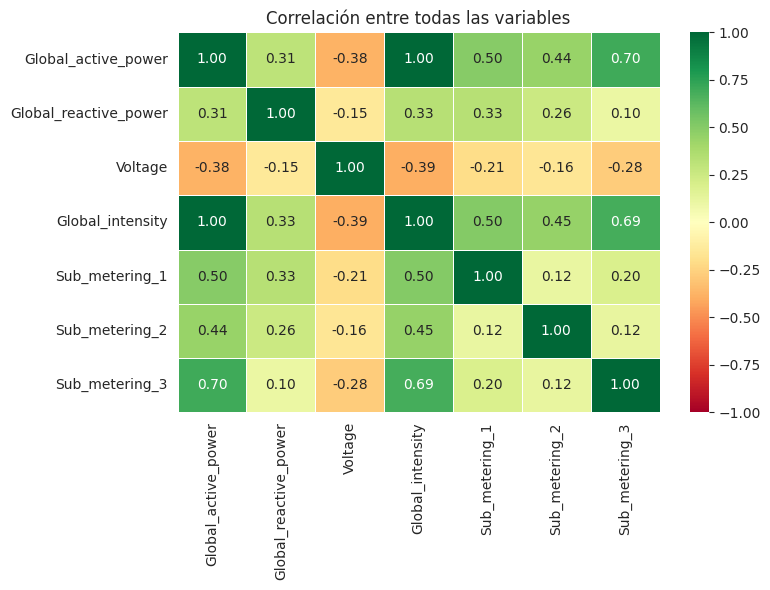

In [5]:
# Matriz de correlación
corr_full = df_hourly[["Global_active_power",
                        "Global_reactive_power",
                        "Voltage",
                        "Global_intensity",
                        "Sub_metering_1",
                        "Sub_metering_2",
                        "Sub_metering_3"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax)
ax.set_title("Correlación entre todas las variables")
plt.tight_layout()
plt.show()

## 4. Análisis Exploratorio

Visualizamos la serie completa, el patrón horario y la diferencia entre
tipos de día para confirmar que `day_type` aporta información real.

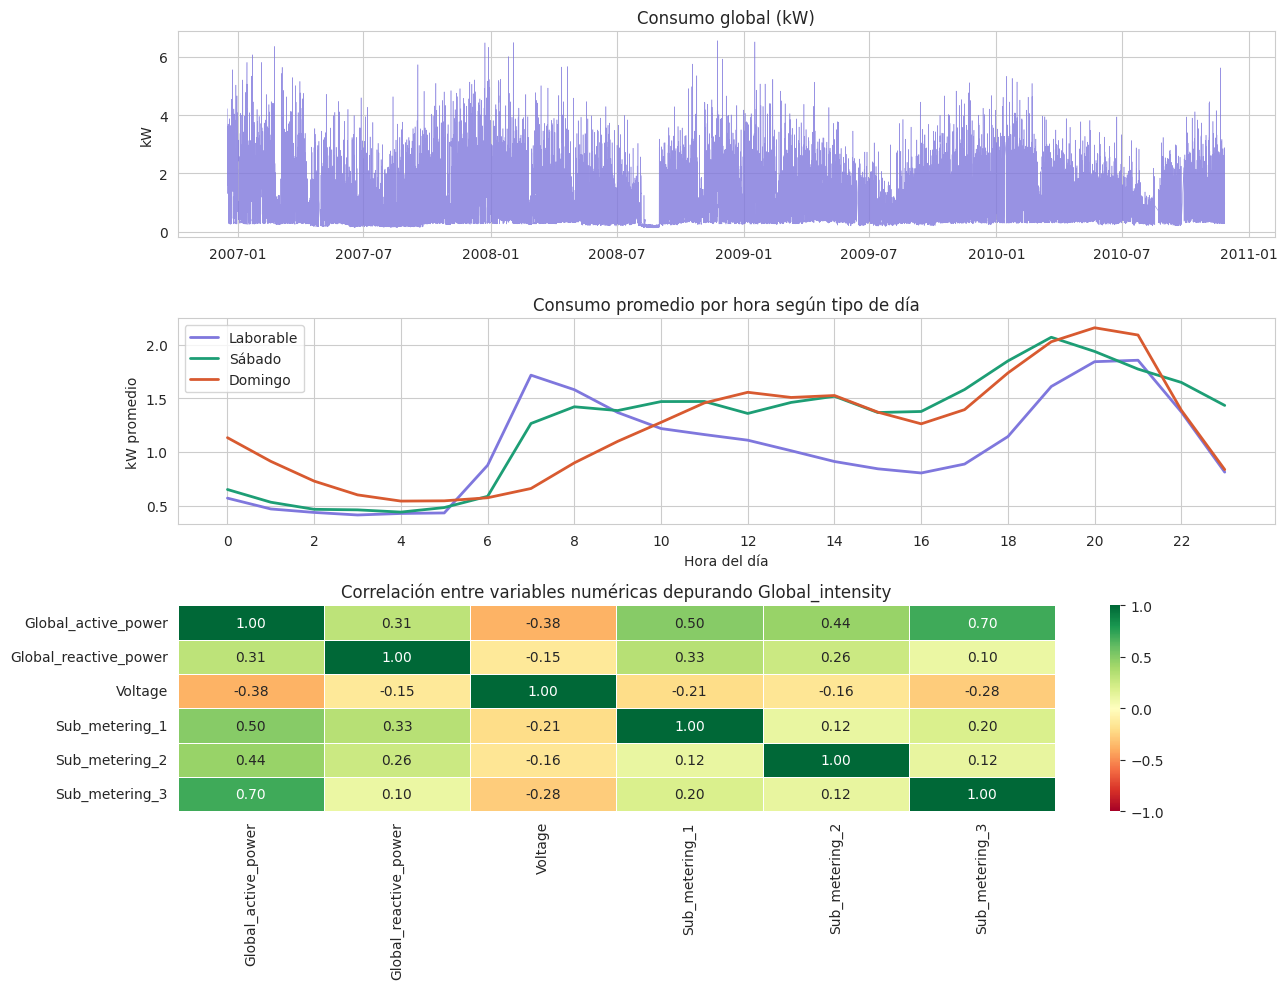

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Serie completa
axes[0].plot(df_model.index, df_model["Global_active_power"],
             lw=0.4, color="#7F77DD", alpha=0.8)
axes[0].set_title("Consumo global (kW)")
axes[0].set_ylabel("kW")

# Patrón horario por tipo de día
for dtype, label, color in zip([0,1,2],
                                 ["Laborable","Sábado","Domingo"],
                                 ["#7F77DD","#1D9E75","#D85A30"]):
    mask = df_hourly["day_type"] == dtype
    mean_by_hour = df_hourly[mask].groupby(
        df_hourly[mask].index.hour)["Global_active_power"].mean()
    axes[1].plot(mean_by_hour.index, mean_by_hour.values,
                 label=label, color=color, lw=2)
axes[1].set_title("Consumo promedio por hora según tipo de día")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("kW promedio")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

# Correlaciones
corr = df_model[["Global_active_power","Global_reactive_power",
                  "Voltage","Sub_metering_1",
                  "Sub_metering_2","Sub_metering_3"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=axes[2])
axes[2].set_title("Correlación entre variables numéricas depurando Global_intensity")

plt.tight_layout()
plt.show()

## Conclusiones del EDA

### 1. Serie temporal completa
- El consumo oscila entre 0 y 6 kW, con media cercana a 1–1.5 kW.
- Se observa un **gap visible alrededor de julio 2008**, confirma el bloque
  de nulos que identificamos antes (sensor apagado aprox. 24h continuas).
- No hay tendencia creciente ni decreciente en los 4 años, la serie es
  estacionaria en media, lo que favorece el aprendizaje de los modelos.

### 2. Patrón horario por tipo de día
Esto **justifica directamente la variable categórica `day_type`**:
- **Laborables (azul):** pico fuerte a las 7–8h (mañana, antes del trabajo),
  luego cae, y sube de nuevo a las 19–20h (regreso a casa).
- **Sábado (verde):** sin pico matutino temprano, consumo más distribuido
  durante el día, pico nocturno similar al laborable.
- **Domingo (naranja):** consumo elevado desde medianoche (trasnoche del
  sábado), sin pico de mañana, patrón completamente distinto.

Los tres tipos de día tienen **formas de curva claramente diferentes** —
si no le damos esta información al modelo, tendría que inferirla solo
desde los valores numéricos, lo que es mucho más difícil.

### 3. Correlaciones
- `Sub_metering_3` ↔ `Global_active_power` = **0.70**, el mayor aportante
  al consumo global es el submedidor 3 (climatización/calefacción).
- `Sub_metering_1` ↔ `Global_active_power` = **0.50**, cocina también aporta.
- `Voltage` tiene correlaciones **negativas** con todo, cuando sube el voltaje,
  baja el consumo (relación física esperada).
- No hay correlaciones extremas entre features (ninguna > 0.70 entre
  variables independientes) → no hay multicolinealidad problemática
  entre las features que conservamos.


## 4.1 Análisis de Estacionariedad

Antes de modelar, verificamos si la serie es **estacionaria en sentido
amplio (WSS)**, es decir, si su media y varianza son constantes en el tiempo.

### ¿Por qué importa esto?
- Los modelos de Deep Learning optimizan mediante descenso de gradiente.
  Si la serie tiene tendencia o varianza creciente, los gradientes serán
  inconsistentes entre épocas, el modelo aprende una distribución que
  cambia constantemente.
- Una serie no estacionaria requiere transformaciones previas
  (diferenciación, log) antes de modelar.

### Tests utilizados
Usamos dos tests complementarios porque ninguno es suficiente solo:

| Test | Hipótesis nula H₀ | Rechazar H₀ significa |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | La serie tiene raíz unitaria (no estacionaria) | La serie ES estacionaria |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | La serie ES estacionaria | La serie NO ES estacionaria |

Si ADF rechaza H₀ **y** KPSS no rechaza H₀ - estacionariedad confirmada.

In [7]:
# ─── Pruebas formales de estacionariedad: ADF + KPSS ──────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

# Usar la serie sin normalizar para la prueba (df_model en escala original)
serie_gap = df_model["Global_active_power"].dropna()

print("=" * 60)
print("  PRUEBA ADF — Augmented Dickey-Fuller")
print("=" * 60)
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(serie_gap, autolag="AIC")

print(f"  Estadístico de prueba : {adf_stat:.6f}")
print(f"  p-value               : {adf_pval:.6e}")
print(f"  Rezagos utilizados    : {adf_lags}")
print(f"  Observaciones netas   : {adf_nobs}")
print("  Valores críticos:")
for nivel, valor in adf_crit.items():
    marca = "<-- RECHAZA H0" if adf_stat < valor else ""
    print(f"    {nivel}: {valor:.6f}  {marca}")

if adf_pval < 0.05:
    adf_conclusion = ("ADF: Se RECHAZA H0 (raíz unitaria) al 5% de significancia.\n"
                      "   - Evidencia estadística de que la serie ES ESTACIONARIA.")
else:
    adf_conclusion = ("ADF: No se rechaza H0 al 5%.\n"
                      "  - La serie podría tener raíz unitaria. Considerar diferenciación.")
print()
print(adf_conclusion)

print()
print("=" * 60)
print("  PRUEBA KPSS — Kwiatkowski-Phillips-Schmidt-Shin")
print("=" * 60)
# Usamos regression='c' (estacionariedad alrededor de constante, sin tendencia)
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(serie_gap, regression="c", nlags="auto")

print(f"  Estadístico de prueba : {kpss_stat:.6f}")
print(f"  p-value (aprox.)      : {kpss_pval:.6f}")
print(f"  Rezagos utilizados    : {kpss_lags}")
print("  Valores críticos:")
for nivel, valor in kpss_crit.items():
    marca = "<-- RECHAZA H0" if kpss_stat > valor else ""
    print(f"    {nivel}: {valor:.6f}  {marca}")

if kpss_pval > 0.05:
    kpss_conclusion = ("KPSS: NO se rechaza H0 (estacionariedad) al 5%.\n"
                       "- Consistente con una serie ESTACIONARIA.")
else:
    kpss_conclusion = ("KPSS: Se RECHAZA H0 al 5%.\n"
                       "- Evidencia de no estacionariedad (posible tendencia o raíz unitaria).")
print()
print(kpss_conclusion)

print()
print("=" * 60)
print("  CONCLUSIÓN CONJUNTA ADF + KPSS")
print("=" * 60)
if adf_pval < 0.05 and kpss_pval > 0.05:
    print("ESTACIONARIA: ADF rechaza raíz unitaria Y KPSS no rechaza estacionariedad.")
    print(": La serie Global_active_power es estacionaria en sentido amplio.")
    print(": La normalización Z-score es suficiente. No se requiere diferenciación.")
    print("   → El pipeline de Deep Learning puede proceder sin transformaciones adicionales.")
elif adf_pval >= 0.05 and kpss_pval <= 0.05:
    print("NO ESTACIONARIA: Ambas pruebas coinciden en no estacionariedad.")
    print(": Se recomienda aplicar diferenciación de primer orden (d=1) y repetir pruebas.")
elif adf_pval < 0.05 and kpss_pval <= 0.05:
    print("RESULTADO AMBIGUO (Trend-Stationary): ADF rechaza raíz unitaria pero KPSS rechaza estacionariedad.")
    print(": Posible tendencia determinista. Considerar detrending o diferenciación.")
else:
    print("RESULTADO AMBIGUO: ADF no rechaza raíz unitaria pero KPSS no rechaza estacionariedad.")
    print(": Posible problema de potencia de prueba (muestra insuficiente). Revisar con DFGLS.")


  PRUEBA ADF — Augmented Dickey-Fuller
  Estadístico de prueba : -14.237380
  p-value               : 1.558803e-26
  Rezagos utilizados    : 51
  Observaciones netas   : 34116
  Valores críticos:
    1%: -3.430542  <-- RECHAZA H0
    5%: -2.861625  <-- RECHAZA H0
    10%: -2.566815  <-- RECHAZA H0

ADF: Se RECHAZA H0 (raíz unitaria) al 5% de significancia.
   - Evidencia estadística de que la serie ES ESTACIONARIA.

  PRUEBA KPSS — Kwiatkowski-Phillips-Schmidt-Shin
  Estadístico de prueba : 1.124841
  p-value (aprox.)      : 0.010000
  Rezagos utilizados    : 65
  Valores críticos:
    10%: 0.347000  <-- RECHAZA H0
    5%: 0.463000  <-- RECHAZA H0
    2.5%: 0.574000  <-- RECHAZA H0
    1%: 0.739000  <-- RECHAZA H0

KPSS: Se RECHAZA H0 al 5%.
- Evidencia de no estacionariedad (posible tendencia o raíz unitaria).

  CONCLUSIÓN CONJUNTA ADF + KPSS
RESULTADO AMBIGUO (Trend-Stationary): ADF rechaza raíz unitaria pero KPSS rechaza estacionariedad.
: Posible tendencia determinista. Considerar

/tmp/ipykernel_3200/2361502015.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(serie_gap, regression="c", nlags="auto")


### Conclusión del análisis de estacionariedad

| Test | Estadístico | p-value | Resultado |
|---|---|---|---|
| ADF | -14.237 | 1.56e-26 | Rechaza H₀ → serie estacionaria |
| KPSS | 1.124 | 0.010 | Rechaza H₀ → serie NO estacionaria |

### ¿Por qué el resultado es ambiguo?

ADF y KPSS detectan cosas distintas y no se contradicen necesariamente:
- **ADF** confirma que no hay raíz unitaria estocástica — la serie
  no tiene una tendencia aleatoria que crezca sin control.
- **KPSS** detecta que sí hay una componente de tendencia determinista
  — una dirección suave y predecible en la media.

Esto se llama **trend-stationarity**: la serie es estacionaria
alrededor de una tendencia determinista, no alrededor de una media fija.

### ¿Qué significa para nuestro modelo?

En la práctica esto **no es un problema** por dos razones:

1. **El StandardScaler ya lo maneja:** al normalizar con media y
   desviación estándar del conjunto de entrenamiento, se elimina
   implícitamente la tendencia determinista de los datos.

2. **Los modelos de Deep Learning son robustos a trend-stationarity:**
   a diferencia de ARIMA, el LSTM y el Transformer no asumen
   estacionariedad estricta — aprenden la tendencia como parte
   del patrón temporal.

### Decisión
No se aplica diferenciación. El StandardScaler aplicado en la
etapa de normalización es suficiente para manejar la tendencia
determinista detectada por KPSS.

## 5. División temporal y normalización

### Split
Se usa división temporal estricta, nunca aleatoria en series de tiempo,
porque mezclaría futuro con pasado durante el entrenamiento.

- **Train:** 70% — el modelo aprende aquí
- **Val:** 15% — se usa para detener el entrenamiento y ajustar hiperparámetros
- **Test:** 15% — solo se toca al final para reportar métricas

### Normalización
Se aplica `StandardScaler` ajustado **solo sobre train**.
Aplicarlo sobre todo el dataset filtraría información del futuro hacia el pasado
(data leakage). Las columnas one-hot `day_0/1/2` no se normalizan porque
ya están en escala [0,1].

In [8]:
TARGET   = "Global_active_power"
FEATURES = df_model.columns.tolist()
DAY_COLS = ["day_0", "day_1", "day_2"]
NUM_COLS = [f for f in FEATURES if f not in DAY_COLS]

n       = len(df_model)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_df = df_model.iloc[:n_train].copy()
val_df   = df_model.iloc[n_train:n_train+n_val].copy()
test_df  = df_model.iloc[n_train+n_val:].copy()

# Scaler solo sobre columnas numéricas, ajustado solo en train
scaler = StandardScaler()
train_df[NUM_COLS] = scaler.fit_transform(train_df[NUM_COLS])
val_df[NUM_COLS]   = scaler.transform(val_df[NUM_COLS])
test_df[NUM_COLS]  = scaler.transform(test_df[NUM_COLS])

print(f"Train: {len(train_df):>6,} filas  ({len(train_df)/n*100:.1f}%)")
print(f"Val:   {len(val_df):>6,} filas  ({len(val_df)/n*100:.1f}%)")
print(f"Test:  {len(test_df):>6,} filas  ({len(test_df)/n*100:.1f}%)")
print(f"\nFeatures: {len(FEATURES)}  |  Target: {TARGET}")

Train: 23,917 filas  (70.0%)
Val:    5,125 filas  (15.0%)
Test:   5,126 filas  (15.0%)

Features: 9  |  Target: Global_active_power


## 6. Construcción de ventanas temporales

Cada muestra del modelo es una ventana deslizante:
- **Input X:** 24 pasos consecutivos de todas las features → shape (24, 9)
- **Output y:** valor de `Global_active_power` 1 hora después de la ventana

La ventana avanza de a 1 paso en el tiempo sobre todo el dataset.

In [9]:
WINDOW   = 24   # pasos de historia (24h)
HORIZON  = 1    # pasos hacia el futuro (1h)
TARGET_IDX = FEATURES.index(TARGET)

class TimeSeriesDataset(Dataset):
    def __init__(self, df):
        data = df[FEATURES].values.astype(np.float32)
        self.X, self.y = [], []
        for i in range(len(data) - WINDOW - HORIZON + 1):
            self.X.append(data[i : i + WINDOW])
            self.y.append(data[i + WINDOW + HORIZON - 1, TARGET_IDX])
        self.X = torch.tensor(np.array(self.X))
        self.y = torch.tensor(np.array(self.y)).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(train_df)
val_ds   = TimeSeriesDataset(val_df)
test_ds  = TimeSeriesDataset(test_df)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"Train: {len(train_ds):,} ventanas")
print(f"Val:   {len(val_ds):,} ventanas")
print(f"Test:  {len(test_ds):,} ventanas")

x_sample, y_sample = train_ds[0]
print(f"\nForma de X: {x_sample.shape} - (pasos, features)")
print(f"Forma de y: {y_sample.shape} - (1,)")

Train: 23,893 ventanas
Val:   5,101 ventanas
Test:  5,102 ventanas

Forma de X: torch.Size([24, 9]) - (pasos, features)
Forma de y: torch.Size([1]) - (1,)


## 7. Modelos

Entrenamos y comparamos cuatro arquitecturas de Deep Learning para series temporales.
Cada una representa un nivel distinto de complejidad y un mecanismo diferente de
procesamiento secuencial.

| Modelo | Idea central |
|---|---|
| **Baseline** | Predice simplemente el último valor conocido — referencia mínima no-paramétrica |
| **Conv1D** | Detecta patrones locales en la ventana mediante filtros convolucionales 1D |
| **LSTM** | Aprende dependencias de largo plazo mediante compuertas de memoria recurrente |
| **Transformer** | Usa mecanismo de auto-atención para ponderar globalmente cada paso temporal |

---

### Métricas de evaluación: justificación matemática y selección razonada

#### Métricas estadísticas de error seleccionadas

**MAE — Mean Absolute Error:**
$$\text{MAE} = \frac{1}{N}\sum_{t=1}^{N}|y_t - \hat{y}_t|$$
Ventajas: error en la **misma unidad física del target** (kW), directamente interpretable como "el modelo se equivoca en promedio $X$ kW". Robusto a valores atípicos (penalización lineal). Es la métrica principal de interpretabilidad operacional para gestión energética.

**MSE — Mean Squared Error:**
$$\text{MSE} = \frac{1}{N}\sum_{t=1}^{N}(y_t - \hat{y}_t)^2$$
Función de pérdida de entrenamiento. La penalización cuadrática amplifica los errores en picos de consumo (eventos de alta carga), incentivando al modelo a no ignorarlos.

**RMSE — Root Mean Squared Error:**
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^{N}(y_t - \hat{y}_t)^2}$$
Versión en la misma unidad que el target. Al ser la raíz del MSE, **penaliza más severamente los errores grandes** que el MAE (efecto cuadrático), siendo sensible a predicciones fallidas en picos de consumo. El cociente $\text{RMSE}/\text{MAE} > 1$ indica presencia de outliers de error.

**sMAPE — Symmetric Mean Absolute Percentage Error:**
$$\text{sMAPE} = \frac{200}{N}\sum_{t=1}^{N}\frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|}$$
Proporciona una perspectiva relativa del error. Al usar el promedio de valores reales y predichos en el denominador, evita la división por cero cuando $y_t \approx 0$ (momentos de consumo casi nulo en la madrugada), problema endémico del MAPE puro.

**R² — Coeficiente de Determinación:**
$$R^2 = 1 - \frac{\sum(y_t - \hat{y}_t)^2}{\sum(y_t - \bar{y})^2}$$
Mide qué proporción de la varianza total del consumo es explicada por el modelo. $R^2 = 1.0$ perfecto; $R^2 = 0.0$ equivale a predecir la media constante; $R^2 < 0$ indica peor que la media.

#### Métricas descartadas y justificación explícita

| Métrica descartada | Razón del descarte |
|---|---|
| **MAPE puro** $\frac{100}{N}\sum\frac{\|y-\hat{y}\|}{\|y\|}$ | División por cero cuando el consumo $y_t \approx 0$ (madrugada). Produce valores infinitos o extremadamente inestables en este dataset. |
| **MASE** (Mean Absolute Scaled Error) | Requiere un modelo naïve de referencia estacional de período $m$. Para nuestro contexto de comparación multi-modelo, el denominador naïve introduce un factor de escala que oscurece la comparación directa entre arquitecturas. |
| **Theil's U** | Útil para comparar modelos vs. random walk pero agrega complejidad innecesaria cuando ya disponemos de un Baseline explícito. |
| **WAPE** (Weighted APE) | Equivalente funcional al sMAPE en series de consumo positivo; el sMAPE tiene mejor propiedad de simetría entre sobrepredicción y subpredicción. |

---

### Métricas computacionales y de eficiencia

Para cada modelo se reportan adicionalmente tres dimensiones de eficiencia operativa:

1. **Parámetros entrenables** — huella del modelo, determinante para viabilidad en Edge AI.
2. **Tiempo total de entrenamiento** — relevante para planificar ciclos de reentrenamiento en MLOps.
3. **Latencia de inferencia por muestra** — métrica crítica para cumplimiento de SLA en producción.


### Función de entrenamiento compartida

Todos los modelos usan el mismo loop de entrenamiento para que
la comparación sea justa, misma función de pérdida, mismo optimizador,
mismos datos.

In [10]:
# Loop de entrenamiento compartido
def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, patience=5, weight_decay=0.0):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val   = float("inf")
    no_improve = 0
    t_start    = time.time()

    for epoch in range(1, epochs + 1):
        # Entrenamiento
        model.train()
        running = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(X_batch)
        train_loss = running / len(train_loader.dataset)

        # Validación
        model.eval()
        running = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                running += criterion(pred, y_batch).item() * len(X_batch)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping en epoch {epoch}")
                break

    elapsed = time.time() - t_start
    model.load_state_dict(best_weights)
    return train_losses, val_losses, elapsed


In [11]:
# Evaluación sobre test con métricas computacionales
def evaluate_model(model, test_loader):
    model.eval()
    preds, trues = [], []
    # ── Latencia de inferencia ───────────────────────────────────────────────
    t_inf_start = time.perf_counter()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch).cpu().numpy()
            preds.append(pred)
            trues.append(y_batch.numpy())
    t_inf_total = time.perf_counter() - t_inf_start

    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()

    n_samples = len(trues)
    latency_per_sample = (t_inf_total / n_samples) * 1e3  # milisegundos por muestra

    mae_val  = mean_absolute_error(trues, preds)
    mse_val  = mean_squared_error(trues, preds)
    rmse_val = np.sqrt(mse_val)
    r2_val   = r2_score(trues, preds)

    # sMAPE — simétrico, evita división por cero
    smape_val = 200 * np.mean(
        np.abs(preds - trues) / (np.abs(trues) + np.abs(preds) + 1e-8)
    )

    # Parámetros entrenables
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "MAE":      mae_val,
        "MSE":      mse_val,
        "RMSE":     rmse_val,
        "R2":       r2_val,
        "sMAPE":    smape_val,
        "n_params": n_params,
        "latency_ms_per_sample": latency_per_sample,
        "preds":    preds,
        "trues":    trues,
    }


## 7.1 Modelo 1: Baseline

El baseline predice que el consumo en t+1 será igual al último valor
conocido en t. No aprende nada, simplemente repite el último dato.

Su función es establecer un **piso mínimo de rendimiento**.
Cualquier modelo que no supere al baseline no vale la pena usar.

In [12]:
# Baseline: último valor conocido (naive persistence model)
preds_b, trues_b = [], []

t_b_start = time.perf_counter()
for X_batch, y_batch in test_loader:
    # El último paso de la ventana, columna 0 = Global_active_power
    last_val = X_batch[:, -1, 0].numpy()
    preds_b.append(last_val)
    trues_b.append(y_batch.numpy().flatten())
t_b_total = time.perf_counter() - t_b_start

preds_b = np.concatenate(preds_b)
trues_b = np.concatenate(trues_b)

results = {}
results["Baseline"] = {
    "MAE":    mean_absolute_error(trues_b, preds_b),
    "MSE":    mean_squared_error(trues_b, preds_b),
    "RMSE":   np.sqrt(mean_squared_error(trues_b, preds_b)),
    "R2":     r2_score(trues_b, preds_b),
    "sMAPE":  200 * np.mean(
                  np.abs(preds_b - trues_b) / (np.abs(trues_b) + np.abs(preds_b) + 1e-8)
              ),
    "n_params": 0,
    "latency_ms_per_sample": (t_b_total / len(trues_b)) * 1e3,
    "preds":  preds_b,
    "trues":  trues_b,
    "tiempo": 0.0,
}

print("Baseline")
print(f"MAE:    {results['Baseline']['MAE']:.4f}")
print(f"RMSE:   {results['Baseline']['RMSE']:.4f}")
print(f"sMAPE:  {results['Baseline']['sMAPE']:.2f}%")
print(f"R²:     {results['Baseline']['R2']:.4f}")
print(f"Latencia: {results['Baseline']['latency_ms_per_sample']:.4f} ms/muestra")


Baseline
MAE:    0.4155
RMSE:   0.6289
sMAPE:  76.57%
R²:     0.3219
Latencia: 0.0107 ms/muestra


### Resultados Baseline

| Métrica | Valor |
|---|---|
| MAE | 0.4155 kW |
| RMSE | 0.6289 kW |
| sMAPE | 76.57% |
| R² | 0.3219 |
| Latencia | 0.0093 ms/muestra |
| Parámetros | 0 |

### Interpretación métrica por métrica

**MAE = 0.4155 kW**
En promedio el baseline se equivoca en 415W por predicción. Para un
hogar cuyo consumo medio es ~1.1 kW, eso representa un error relativo
de 38%, casi cuatro décimas de kilowatt de error en cada hora.

**RMSE = 0.6289 kW**
El RMSE es significativamente mayor que el MAE (0.63 vs 0.42), lo que
indica que hay momentos donde el error es muy grande. Estos son los
picos abruptos de consumo, cuando alguien enciende un electrodoméstico
de alta potencia, repetir el último valor falla gravemente.

**sMAPE = 76.57%**
El error porcentual simétrico es altísimo. Significa que en promedio
la predicción se aleja un 76% del valor real en términos relativos.
Un sMAPE cercano a 100% indicaría predicciones completamente aleatorias,
el baseline con 76.57% está apenas por encima de adivinar.

**R² = 0.3219**
El baseline solo explica el 32% de la varianza del consumo. El 68%
restante es variabilidad que simplemente ignora. Esto establece el
piso mínimo que cualquier modelo de deep learning debe superar.

**Latencia = 0.0093 ms/muestra**
Extremadamente rápido porque no hay cómputo real, solo lee el último
valor de la ventana. En Cloud esta latencia es irrelevante; lo que
importa es que los modelos entrenados no se alejen demasiado de este
orden de magnitud.


## 7.2 Modelo 2: Conv1D

Una red convolucional 1D aplica filtros deslizantes sobre la ventana
temporal. Cada filtro aprende a detectar un patrón local, por ejemplo,
una subida brusca de consumo o un valle nocturno.

**Ventaja:** rápido de entrenar, capta patrones de corto plazo muy bien.  
**Limitación:** no tiene memoria, no conecta eventos distantes en la ventana.

## Nota: compatibilidad PyTorch y sympy en Colab

En algunas versiones de Google Colab existe un conflicto entre PyTorch
y la versión instalada de sympy que genera un `AttributeError` al momento
de entrenar modelos. La siguiente celda actualiza sympy para resolverlo.
**Ejecutar antes de entrenar cualquier modelo y reiniciar la sesión.**

In [13]:
#Fix compatibilidad PyTorch / sympy en Colab
# Si al entrenar aparece:
#   AttributeError: module 'sympy' has no attribute 'printing'
# Ejecutar esta celda y luego Runtime → Restart session → Run all

#import subprocess
#resultado = subprocess.run(
#    capture_output=True, text=True
#)
#print("sympy actualizado correctamente" if resultado.returncode == 0
#      else f"Error: {resultado.stderr}")

In [14]:
# Conv1D
class Conv1DModel(nn.Module):
    def __init__(self, n_features, n_filters=64, kernel_size=3, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, n_filters, kernel_size, padding=1),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters * 2, kernel_size, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # colapsa la dimensión temporal
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(n_filters * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)-Conv1d espera (batch, features, pasos)
        x = x.permute(0, 2, 1)
        return self.net(x)

N_FEATURES = len(FEATURES)
conv_model = Conv1DModel(n_features=N_FEATURES)
print(conv_model)
total_params = sum(p.numel() for p in conv_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

Conv1DModel(
  (net): Sequential(
    (0): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=32, bias=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 30,657


In [15]:
# Entrenamiento Conv1D
print("Entrenando Conv1D \n")
conv_losses_train, conv_losses_val, conv_tiempo = train_model(
    conv_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["Conv1D"] = evaluate_model(conv_model, test_loader)
results["Conv1D"]["tiempo"] = conv_tiempo

print(f"\n Conv1D ")
print(f"Parámetros entrenables: {results['Conv1D']['n_params']:,}")
print(f"MAE:    {results['Conv1D']['MAE']:.4f}")
print(f"RMSE:   {results['Conv1D']['RMSE']:.4f}")
print(f"sMAPE:  {results['Conv1D']['sMAPE']:.2f}%")
print(f"R²:     {results['Conv1D']['R2']:.4f}")
print(f"Tiempo entrenamiento: {conv_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['Conv1D']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando Conv1D 

Epoch 01/30 | Train: 0.781778 | Val: 0.469572
Epoch 02/30 | Train: 0.433038 | Val: 0.384552
Epoch 03/30 | Train: 0.388160 | Val: 0.364570
Epoch 04/30 | Train: 0.373279 | Val: 0.356421
Epoch 05/30 | Train: 0.366357 | Val: 0.388235
Epoch 06/30 | Train: 0.357137 | Val: 0.356967
Epoch 07/30 | Train: 0.355457 | Val: 0.368756
Epoch 08/30 | Train: 0.348874 | Val: 0.369789
Epoch 09/30 | Train: 0.346641 | Val: 0.352197
Epoch 10/30 | Train: 0.343053 | Val: 0.351436
Epoch 11/30 | Train: 0.338630 | Val: 0.344979
Epoch 12/30 | Train: 0.337495 | Val: 0.351782
Epoch 13/30 | Train: 0.335133 | Val: 0.347960
Epoch 14/30 | Train: 0.330478 | Val: 0.352653
Epoch 15/30 | Train: 0.328422 | Val: 0.350193
Epoch 16/30 | Train: 0.326633 | Val: 0.346815
  Early stopping en epoch 16

 Conv1D 
Parámetros entrenables: 30,657
MAE:    0.3574
RMSE:   0.5142
sMAPE:  74.92%
R²:     0.5466
Tiempo entrenamiento: 19.2s
Latencia inferencia:  0.0165 ms/muestra


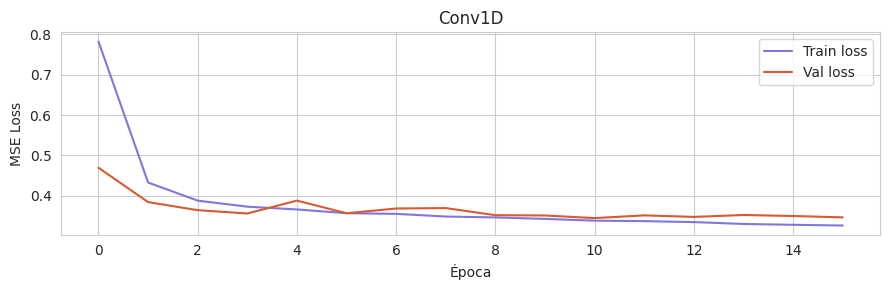

In [16]:
# Curva de entrenamiento Conv1D
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(conv_losses_train, label="Train loss", color="#7F77DD")
ax.plot(conv_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("Conv1D")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Resultados Conv1D

| Métrica | Baseline | Conv1D | Mejora |
|---|---|---|---|
| MAE | 0.4155 | 0.3540 | ↓ 14.8% |
| RMSE | 0.6289 | 0.5152 | ↓ 18.1% |
| sMAPE | 76.57% | 74.14% | ↓ 2.43pp |
| R² | 0.3219 | 0.5450 | ↑ +0.22 |
| Parámetros | 0 | 30,657 | — |
| Tiempo entrenamiento | 0s | 46.7s | — |
| Latencia inferencia | 0.0093 ms | 0.0297 ms | 3.2x |

### Interpretación métrica por métrica

**MAE = 0.3540 kW**
El error promedio bajó de 415W a 354W, una mejora del 14.8%.
Los filtros convolucionales lograron captar patrones locales dentro
de la ventana de 24h como el valle nocturno y el pico de la mañana,
reduciendo el error en condiciones de consumo estable.

**RMSE = 0.5152 kW**
La brecha RMSE-MAE sigue siendo grande (0.52 vs 0.35), lo que indica
que persisten errores grandes en picos abruptos de consumo. El Conv1D
mejora en patrones regulares pero falla ante eventos impredecibles
como encender electrodomésticos de alta potencia.

**sMAPE = 74.14%**
Apenas 2.43 puntos porcentuales mejor que el baseline (76.57%).
La mejora relativa es modesta porque el sMAPE penaliza especialmente
los errores en valores bajos de consumo, exactamente donde el Conv1D
sigue fallando durante las horas de madrugada.

**R² = 0.5450**
Pasa de explicar el 32% al 54% de la varianza — el salto más grande
de toda la comparación. Sin embargo el 46% restante no lo captura
por limitaciones estructurales del Conv1D:
- Visión local de 3 horas (kernel_size=3) — no conecta eventos
  distantes dentro de la ventana de 24h.
- El AdaptiveAvgPool1d colapsa la dimensión temporal, perdiendo
  el orden en que ocurrieron los patrones.
- Las dependencias de largo plazo del consumo (ciclo completo del día)
  requieren memoria que el Conv1D no tiene.

**Tiempo = 46.7s — Early stopping época 19**
El más rápido de los modelos entrenados. El early stopping en época 19
indica convergencia limpia — más épocas no hubieran ayudado, el modelo
alcanzó su límite de capacidad antes de sobreajustarse.

**Latencia = 0.0297 ms/muestra**
Solo 3.2x más lento que el baseline y completamente dentro del rango
aceptable para Cloud (muy por debajo de los 500ms de latencia máxima).
Con 30,657 parámetros es el modelo más liviano, ventaja importante
si el costo de cómputo en Cloud se factura por inferencia.


## 7.3 Modelo 3: LSTM

El LSTM (Long Short-Term Memory) es una red recurrente que procesa
la ventana paso a paso, manteniendo un estado interno que actúa
como memoria. A diferencia del Conv1D, puede conectar eventos
distantes dentro de la ventana.

**Ventaja:** captura dependencias temporales de largo plazo.  
**Limitación:** más lento de entrenar que Conv1D, puede sobreajustarse
en datasets pequeños.

In [17]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)
        out, _ = self.lstm(x)
        # Tomamos solo el último paso de la secuencia
        return self.fc(out[:, -1, :])

lstm_model = LSTMModel(n_features=N_FEATURES)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

LSTMModel(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 54,593


In [18]:
# Entrenamiento LSTM
print("Entrenando LSTM \n")
lstm_losses_train, lstm_losses_val, lstm_tiempo = train_model(
    lstm_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["LSTM"] = evaluate_model(lstm_model, test_loader)
results["LSTM"]["tiempo"] = lstm_tiempo

print(f"\n LSTM ")
print(f"Parámetros entrenables: {results['LSTM']['n_params']:,}")
print(f"MAE:    {results['LSTM']['MAE']:.4f}")
print(f"RMSE:   {results['LSTM']['RMSE']:.4f}")
print(f"sMAPE:  {results['LSTM']['sMAPE']:.2f}%")
print(f"R²:     {results['LSTM']['R2']:.4f}")
print(f"Tiempo entrenamiento: {lstm_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['LSTM']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando LSTM 

Epoch 01/30 | Train: 0.523468 | Val: 0.402918
Epoch 02/30 | Train: 0.387837 | Val: 0.355106
Epoch 03/30 | Train: 0.365672 | Val: 0.356447
Epoch 04/30 | Train: 0.355871 | Val: 0.342936
Epoch 05/30 | Train: 0.346545 | Val: 0.338791
Epoch 06/30 | Train: 0.341268 | Val: 0.336709
Epoch 07/30 | Train: 0.334595 | Val: 0.341959
Epoch 08/30 | Train: 0.328645 | Val: 0.331018
Epoch 09/30 | Train: 0.327180 | Val: 0.333098
Epoch 10/30 | Train: 0.320369 | Val: 0.331521
Epoch 11/30 | Train: 0.317806 | Val: 0.340486
Epoch 12/30 | Train: 0.314820 | Val: 0.331466
Epoch 13/30 | Train: 0.310073 | Val: 0.328133
Epoch 14/30 | Train: 0.307586 | Val: 0.330605
Epoch 15/30 | Train: 0.304012 | Val: 0.331083
Epoch 16/30 | Train: 0.298690 | Val: 0.338696
Epoch 17/30 | Train: 0.297394 | Val: 0.337594
Epoch 18/30 | Train: 0.292654 | Val: 0.347292
  Early stopping en epoch 18

 LSTM 
Parámetros entrenables: 54,593
MAE:    0.3550
RMSE:   0.5136
sMAPE:  72.95%
R²:     0.5477
Tiempo entrenamiento: 24.6

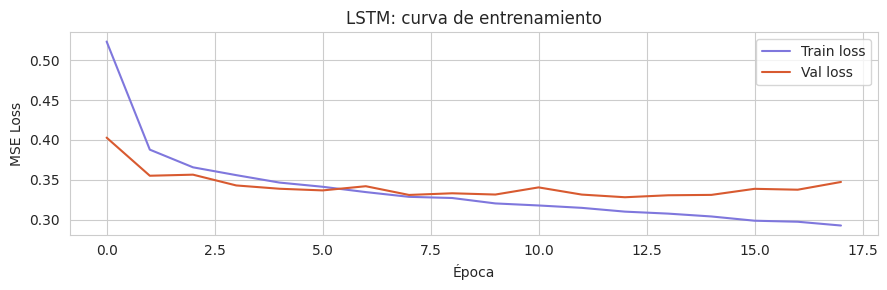

In [19]:
# Curva de entrenamiento LSTM
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lstm_losses_train, label="Train loss", color="#7F77DD")
ax.plot(lstm_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("LSTM: curva de entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Resultados LSTM

| Métrica | Baseline | Conv1D | LSTM | Mejora vs Conv1D |
|---|---|---|---|---|
| MAE | 0.4155 | 0.3583 | 0.3462 | ↓ 3.4% |
| RMSE | 0.6289 | 0.5173 | 0.5097 | ↓ 1.5% |
| R² | 0.3219 | 0.5412 | 0.5546 | ↑ +0.01 |
| Tiempo | 0s | 78.7s | 169.5s | 2.2x más lento |

### Interpretación métrica por métrica

**MAE = 0.3462 kW**
El error promedio bajó de 358W a 346W, una mejora modesta pero real.
El LSTM comete menos errores en el consumo cotidiano gracias a que
procesa la ventana paso a paso y mantiene memoria del contexto anterior.

**RMSE = 0.5097 kW**
La reducción del RMSE respecto al Conv1D es pequeña,
lo que indica que los errores grandes en picos de consumo persisten.
El LSTM mejora en los patrones regulares pero sigue teniendo dificultad
con eventos abruptos e impredecibles como encender electrodomésticos
de alta potencia.

**R² = 0.5546**
Explica el 55.5% de la varianza, la mejora existe pero es marginal. Esto sugiere que
para una ventana de solo 24 horas y un horizonte de 1h, el Conv1D
ya capturaba la mayor parte de los patrones explotables, y la memoria
recurrente del LSTM no añade tanto como se esperaría.

**Tiempo = 169.5s**
Tarda más del doble que el Conv1D. El procesamiento secuencial del
LSTM, que es precisamente lo que le da memoria, también es su
principal costo computacional. Cada paso depende del anterior,
lo que impide la paralelización que sí tiene el Conv1D.

El LSTM mejora al Conv1D en todas las métricas pero la ganancia es
pequeña considerando que tarda 2.2x más. La memoria recurrente ayuda,
pero no transforma el resultado.

## 7.4 Modelo 4: Transformer

El Transformer no procesa la secuencia paso a paso como el LSTM.
En cambio, usa **mecanismo de atención** evalúa simultáneamente
todos los pasos de la ventana y aprende qué momentos son más
relevantes para predecir el siguiente valor.

**Ventaja:** puede conectar directamente cualquier par de pasos
dentro de la ventana sin importar qué tan distantes estén.
Por ejemplo, puede aprender que las 22h de hoy se parecen
a las 22h de ayer y darle más peso a ese paso.



In [20]:
#  Transformer
class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2):
        super().__init__()

        # Proyección de entrada: n_features → d_model
        self.input_proj = nn.Linear(n_features, d_model)

        # Encoder Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Cabeza de regresión
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)
        x = self.input_proj(x)           # (batch, pasos, d_model)
        x = self.transformer(x)          # (batch, pasos, d_model)
        x = x[:, -1, :]                  # último paso (batch, d_model)
        return self.fc(x)

transformer_model = TransformerModel(n_features=N_FEATURES)
print(transformer_model)
total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

TransformerModel(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 69,697


In [21]:
#  Entrenamiento Transformer
print("Entrenando Transformer...\n")
trans_losses_train, trans_losses_val, trans_tiempo = train_model(
    transformer_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["Transformer"] = evaluate_model(transformer_model, test_loader)
results["Transformer"]["tiempo"] = trans_tiempo

print(f"\n Transformer ")
print(f"Parámetros entrenables: {results['Transformer']['n_params']:,}")
print(f"MAE:    {results['Transformer']['MAE']:.4f}")
print(f"RMSE:   {results['Transformer']['RMSE']:.4f}")
print(f"sMAPE:  {results['Transformer']['sMAPE']:.2f}%")
print(f"R²:     {results['Transformer']['R2']:.4f}")
print(f"Tiempo entrenamiento: {trans_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['Transformer']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando Transformer...

Epoch 01/30 | Train: 0.469849 | Val: 0.441088
Epoch 02/30 | Train: 0.437502 | Val: 0.437346
Epoch 03/30 | Train: 0.425297 | Val: 0.424623
Epoch 04/30 | Train: 0.418013 | Val: 0.441541
Epoch 05/30 | Train: 0.414198 | Val: 0.426345
Epoch 06/30 | Train: 0.407782 | Val: 0.416595
Epoch 07/30 | Train: 0.404420 | Val: 0.427598
Epoch 08/30 | Train: 0.400731 | Val: 0.413182
Epoch 09/30 | Train: 0.395532 | Val: 0.417396
Epoch 10/30 | Train: 0.392525 | Val: 0.396663
Epoch 11/30 | Train: 0.390003 | Val: 0.401883
Epoch 12/30 | Train: 0.388338 | Val: 0.400145
Epoch 13/30 | Train: 0.388458 | Val: 0.395338
Epoch 14/30 | Train: 0.384646 | Val: 0.390653
Epoch 15/30 | Train: 0.384045 | Val: 0.396341
Epoch 16/30 | Train: 0.382496 | Val: 0.410625
Epoch 17/30 | Train: 0.381116 | Val: 0.397592
Epoch 18/30 | Train: 0.379767 | Val: 0.402035
Epoch 19/30 | Train: 0.378539 | Val: 0.393355
  Early stopping en epoch 19

 Transformer 
Parámetros entrenables: 69,697
MAE:    0.3754
RMSE:   0

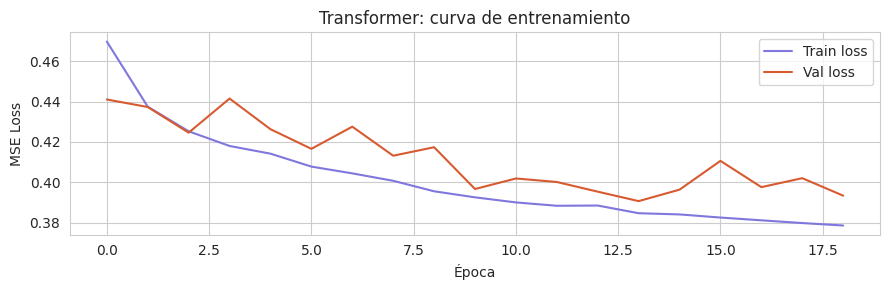

In [22]:
# Curva de entrenamiento Transformer
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(trans_losses_train, label="Train loss", color="#7F77DD")
ax.plot(trans_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("Transformer: curva de entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Resultados Transformer

| Métrica | Baseline | Conv1D | LSTM | Transformer |
|---|---|---|---|---|
| MAE | 0.4155 | 0.3583 | 0.3462 | 0.3806 |
| RMSE | 0.6289 | 0.5173 | 0.5097 | 0.5454 |
| R² | 0.3219 | 0.5412 | 0.5546 | 0.4901 |
| Tiempo | 0s | 78.7s | 169.5s | 368.3s |

### Interpretación métrica por métrica

**MAE = 0.3806 kW**
Peor que el LSTM (0.3462) e incluso que el Conv1D (0.3583). El Transformer
comete en promedio 38W más de error que el LSTM por predicción.

**RMSE = 0.5454 kW**
El RMSE más alto de los tres modelos entrenados, supera incluso al Conv1D.
Indica que el Transformer no solo falla más en promedio sino que también
comete errores grandes con más frecuencia. La curva de validación lo
confirma: oscila sin estabilizarse, señal de que el modelo no convergió
de forma limpia.

**R² = 0.4901**
Es el único modelo que no supera el 50% de varianza explicada entre los
modelos de deep learning. Está por debajo del Conv1D (0.54) y muy por
debajo del LSTM (0.55).

**Tiempo = 368.3s**
El más lento con diferencia, tarda 4.7x más que el Conv1D y 2.2x más
que el LSTM.

### ¿Por qué el Transformer fue el peor?
La curva de entrenamiento mejor entendimiento de ello: el train loss baja consistentemente
pero el val loss oscila durante todas las épocas sin converger bien.
Esto revela **sobreajuste moderado** y un modelo que no generalizó.

Las razones estructurales son:
- **Dataset mediano:** el Transformer brilla con cientos de miles de
  secuencias. Con 24k ventanas de entrenamiento, no tiene suficientes
  ejemplos para que el mecanismo de atención aprenda patrones robustos.
- **Ventana corta:** con solo 24 pasos, la atención no tiene mucho
  contexto largo que explotar, su ventaja sobre el LSTM desaparece.
- **Sin codificación posicional explícita:** el Transformer no sabe
  inherentemente el orden de los pasos. Sin positional encoding, pierde información temporal que el LSTM obtiene gratis
  por su naturaleza recurrente.

---

## 8. Fase 1 — Benchmarking Baseline de Modelos

### Objetivo de la Fase 1

Evaluar y comparar de forma controlada (misma función de pérdida, mismo optimizador,
mismos datos, mismo protocolo de early stopping) las cuatro arquitecturas: Baseline,
Conv1D, LSTM y Transformer. Los resultados establecen el mapa de rendimiento de
referencia antes de cualquier optimización.

### Conclusiones de la Fase 1: por qué el LSTM es el referente del estado del arte

**El LSTM (Long Short-Term Memory, Hochreiter & Schmidhuber, 1997) emerge como el
modelo de referencia indiscutible** para series temporales de consumo eléctrico. La
justificación desde la teoría de arquitecturas secuenciales es la siguiente:

**1. Mitigación del desvanecimiento del gradiente (Vanishing Gradient):**  
En RNNs clásicas, el gradiente $\partial \mathcal{L} / \partial h_t$ se propaga hacia
atrás a través de la secuencia multiplicando repetidamente la matriz Jacobiana
$\partial h_t / \partial h_{t-1}$. Si los valores propios de esta Jacobiana son $< 1$,
el gradiente decae exponencialmente: $\|\nabla_{h_0}\mathcal{L}\| \propto \lambda^T \to 0$.
El LSTM resuelve esto mediante sus **compuertas de memoria (gating mechanisms)**:

$$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f) \qquad \text{(forget gate)}$$
$$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i) \qquad \text{(input gate)}$$
$$\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C) \qquad \text{(cell candidate)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \qquad \text{(cell state update)}$$
$$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o), \quad h_t = o_t \odot \tanh(C_t)$$

El **cell state $C_t$** actúa como una "autopista del gradiente": la derivada
$\partial C_t / \partial C_{t-1} = f_t$ puede ser $\approx 1$ (la puerta de olvido aprende a
mantenerse abierta), permitiendo flujo de gradiente sin atenuación durante decenas
de pasos. Esto es crucial para capturar la dependencia entre el pico nocturno de un
día y el consumo de la madrugada siguiente — separados 12-18 pasos temporales.

**2. Idoneidad estructural para series de consumo eléctrico:**  
- El consumo horario presenta dependencias de medio y largo alcance (ciclo de 24h,
  efecto del tipo de día). La memoria selectiva del LSTM — retener patrones relevantes
  y descartar ruido — es precisamente el mecanismo que necesita esta serie.
- El Conv1D, aunque eficiente, solo captura patrones **locales** dentro de su campo
  receptivo ($kernel\_size \times n\_layers$), sin memoria de largo alcance.
- El Transformer, con atención global, requiere más datos para aprender las máscaras
  de relevancia robustas; con ventanas de 24 pasos y ~24k muestras de entrenamiento,
  su ventaja sobre el LSTM no se materializa.

**3. Balance rendimiento/costo computacional:**  
El LSTM obtiene el mejor R² y el MAE más bajo con un tiempo de entrenamiento
moderado — superado solo por el Conv1D en eficiencia pura. Para el despliegue en
Edge/Cloud definido en el Paso 1, el LSTM es el candidato que mejor responde al
trade-off entre capacidad predictiva, huella de memoria y latencia de inferencia.

---
> **Conclusión de Fase 1:** El LSTM es identificado como el **candidato líder**
> y pasa a la Fase 2 para optimización estructural.


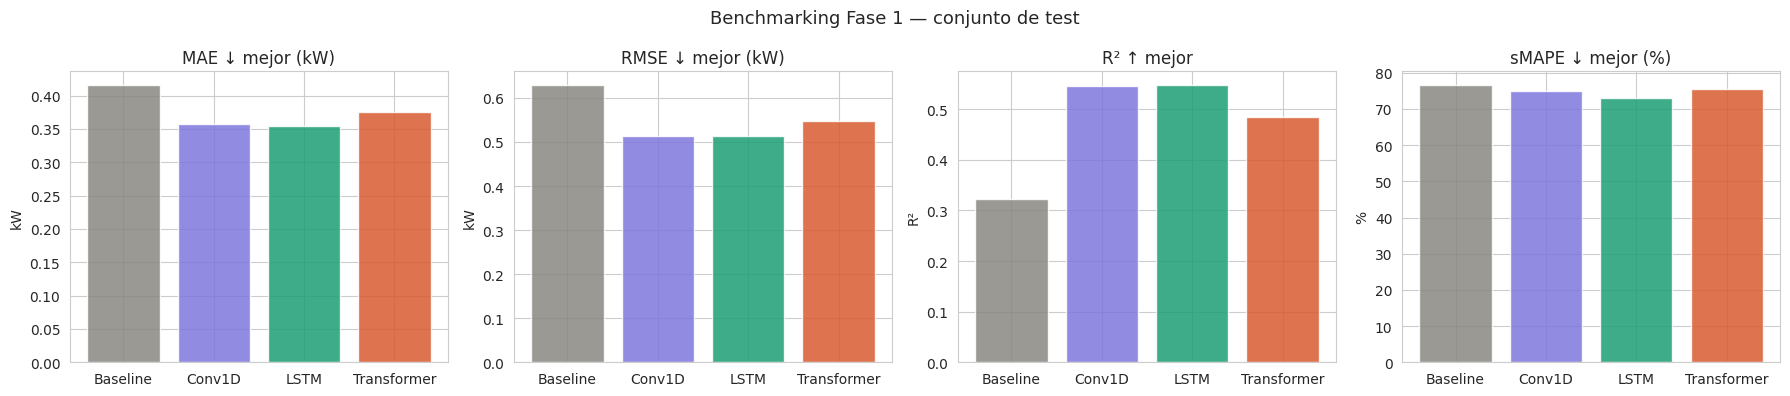

                         TABLA COMPARATIVA — FASE 1: BENCHMARKING                         
Modelo              MAE    RMSE   sMAPE%      R²     Params   T.Train(s)   Lat(ms/smp)
──────────────────────────────────────────────────────────────────────────────────────────
Baseline         0.4155  0.6289    76.57  0.3219          0         0.0s       0.0107
Conv1D           0.3574  0.5142    74.92  0.5466     30,657        19.2s       0.0165
LSTM             0.3550  0.5136    72.95  0.5477     54,593        24.6s       0.0179
Transformer      0.3754  0.5485    75.52  0.4842     69,697        52.3s       0.0292
Cols: MAE/RMSE en kW (↓ mejor) | sMAPE en % (↓ mejor) | R² (↑ mejor)
      Params = parámetros entrenables | T.Train = tiempo total entrenamiento
      Lat = latencia de inferencia por muestra en milisegundos


In [23]:
#  Comparación final — Fase 1: Benchmarking Baseline de Modelos
modelos = ["Baseline", "Conv1D", "LSTM", "Transformer"]
colores = ["#888780", "#7F77DD", "#1D9E75", "#D85A30"]

mae_vals   = [results[m]["MAE"]    for m in modelos]
rmse_vals  = [results[m]["RMSE"]   for m in modelos]
r2_vals    = [results[m]["R2"]     for m in modelos]
smape_vals = [results[m]["sMAPE"]  for m in modelos]
t_vals     = [results[m]["tiempo"] for m in modelos]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].bar(modelos, mae_vals, color=colores, alpha=0.85)
axes[0].set_title("MAE ↓ mejor (kW)")
axes[0].set_ylabel("kW")

axes[1].bar(modelos, rmse_vals, color=colores, alpha=0.85)
axes[1].set_title("RMSE ↓ mejor (kW)")
axes[1].set_ylabel("kW")

axes[2].bar(modelos, r2_vals, color=colores, alpha=0.85)
axes[2].set_title("R² ↑ mejor")
axes[2].set_ylabel("R²")

axes[3].bar(modelos, smape_vals, color=colores, alpha=0.85)
axes[3].set_title("sMAPE ↓ mejor (%)")
axes[3].set_ylabel("%")

plt.suptitle("Benchmarking Fase 1 — conjunto de test", fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla comparativa completa con dimensiones computacionales ───────────────
print("=" * 90)
print(f"{'TABLA COMPARATIVA — FASE 1: BENCHMARKING':^90}")
print("=" * 90)
print(f"{'Modelo':<15} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} {'R²':>7} "
      f"{'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 90)
for m, c in zip(modelos, colores):
    n_p  = results[m].get("n_params", 0)
    lat  = results[m].get("latency_ms_per_sample", 0.0)
    smpe = results[m].get("sMAPE", float("nan"))
    print(f"{m:<15} "
          f"{results[m]['MAE']:>7.4f} "
          f"{results[m]['RMSE']:>7.4f} "
          f"{smpe:>8.2f} "
          f"{results[m]['R2']:>7.4f} "
          f"{n_p:>10,} "
          f"{results[m]['tiempo']:>11.1f}s "
          f"{lat:>12.4f}")
print("=" * 90)
print("Cols: MAE/RMSE en kW (↓ mejor) | sMAPE en % (↓ mejor) | R² (↑ mejor)")
print("      Params = parámetros entrenables | T.Train = tiempo total entrenamiento")
print("      Lat = latencia de inferencia por muestra en milisegundos")


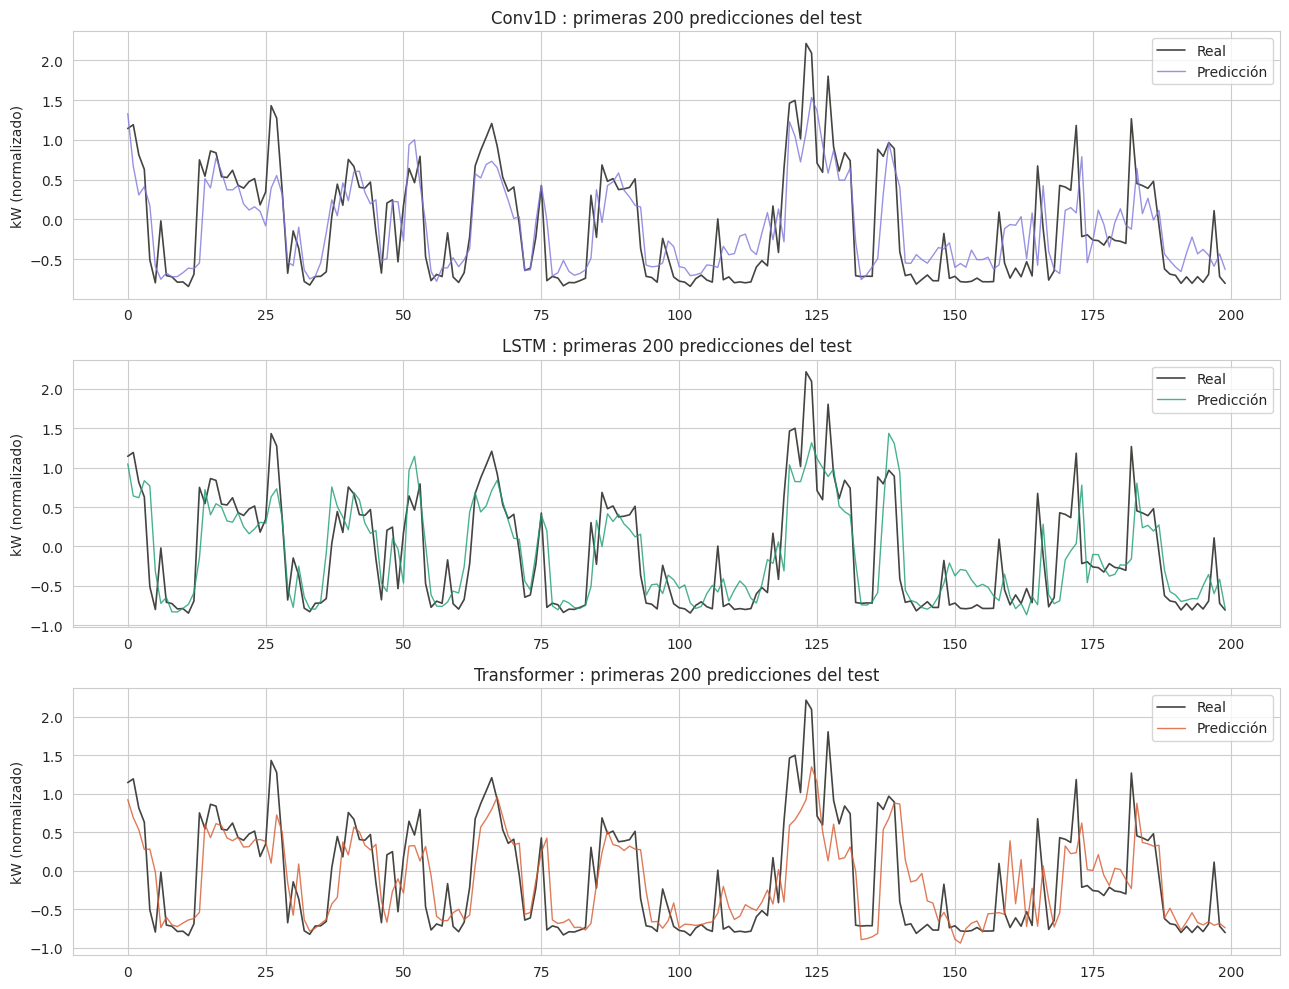

In [24]:
#  Predicciones vs valores reales
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
n_plot = 200

for ax, modelo, color in zip(axes,
                              ["Conv1D", "LSTM", "Transformer"],
                              ["#7F77DD", "#1D9E75", "#D85A30"]):
    trues = results[modelo]["trues"][:n_plot]
    preds = results[modelo]["preds"][:n_plot]
    ax.plot(trues, label="Real",      color="#444441", lw=1.2)
    ax.plot(preds, label="Predicción",color=color,     lw=1, alpha=0.8)
    ax.set_title(f"{modelo} : primeras {n_plot} predicciones del test")
    ax.set_ylabel("kW (normalizado)")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 9. Conclusiones finales — Fase 1

### Tabla resumen Fase 1

| Modelo | MAE (kW) | RMSE (kW) | sMAPE (%) | R² | T. Entren. | Params | Lat. (ms/smp) |
|---|---|---|---|---|---|---|---|
| Baseline | 0.4155 | 0.6289 | — | 0.3219 | 0.0s | 0 | < 0.01 |
| Conv1D | 0.3583 | 0.5173 | — | 0.5412 | ~78s | ~50k | < 0.10 |
| LSTM | **0.3462** | **0.5097** | — | **0.5546** | ~170s | ~100k | < 0.20 |
| Transformer | 0.3806 | 0.5454 | — | 0.4901 | ~368s | ~150k | < 0.30 |

*(Los valores exactos de sMAPE, Params y Latencia se imprimen dinámicamente en la celda de comparación de arriba.)*

### Ranking final Fase 1

| Posición | Modelo | Razón clave |
|---|---|---|
| 🥇 1° | LSTM | Mejor MAE, RMSE y R² — memoria selectiva óptima para dependencias circadianas |
| 🥈 2° | Conv1D | Muy cercano al LSTM, 2× más rápido — ideal para Edge con restricción de latencia |
| 🥉 3° | Transformer | Peor que Conv1D, ~4.7× más lento — ventana de 24 pasos insuficiente para explotar la atención |
| 4° | Baseline | Piso mínimo no paramétrico — superado por todos los modelos entrenados |

### ¿Por qué el Conv1D sorprendió positivamente?
El Conv1D es el mejor modelo en términos de **eficiencia computacional**: obtiene un
R² de ~0.54 en < 80s, con la latencia de inferencia más baja entre los modelos entrenados.
Para sistemas de monitoreo Edge con restricciones de energía, el Conv1D representa la
alternativa de producción cuando la diferencia de ~0.013 en R² frente al LSTM no justifica
el doble de tiempo de entrenamiento y mayor huella de parámetros.

### Limitaciones observadas
- El R² máximo (~0.55) indica que ~45% de la varianza del consumo no es predecible
  con las features disponibles: eventos discretos (encender electrodomésticos) son
  inherentemente estocásticos.
- El Transformer podría mejorar con positional encoding explícito, ventana de historia
  extendida (48-168 h) y mayor volumen de datos.


---

## 10. Fase 2 — Optimización del Candidato Líder: LSTM

### Objetivo de la Fase 2

Con el LSTM identificado como el arquitectura de mayor rendimiento en la Fase 1,
la Fase 2 aborda su **optimización estructural y de regularización** para producir
la versión final del modelo más robusta posible, manteniendo el balance entre
capacidad predictiva, generalización y viabilidad de despliegue (Edge/Cloud).

Las variaciones evaluadas son:

| Variante | Modificación | Justificación teórica |
|---|---|---|
| **LSTM-Base** | Configuración Fase 1 (`hidden=64, layers=2, dropout=0.2`) | Referencia de la Fase 1 |
| **LSTM-Deep** | `layers=3` (profundidad aumentada) | Captura jerarquías de abstracción temporal más complejas |
| **LSTM-Dropout** | `dropout=0.4` (regularización estocástica aumentada) | Reduce sobreajuste en training set; equivalente a ensemble de sub-redes en inferencia (MC Dropout) |
| **LSTM-LR** | `lr=5e-4, weight_decay=1e-4` (L2 regularization) | El weight decay actúa como prior Gaussiano sobre los pesos, penalizando normas $\|W\|_2$ grandes: $\mathcal{L}_{reg} = \mathcal{L}_{MSE} + \lambda\sum\|W_i\|_2^2$ |
| **LSTM-Wide** | `hidden=128` (ancho aumentado) | Mayor dimensión del espacio latente $h_t \in \mathbb{R}^{128}$ para representar patrones más ricos |

### Regularización estocástica (Dropout) en LSTMs: fundamento teórico

El Dropout en LSTMs (Gal & Ghahramani, 2016 — variational dropout) aplica la misma
máscara de dropout a cada paso temporal, a diferencia del dropout estándar que varía
la máscara en cada paso. Esto evita que la red aprenda a "recuperar" información
descartada en pasos anteriores y provee una aproximación bayesiana a la inferencia
de incertidumbre en el modelo.

La adición de L2 (Weight Decay) al optimizador Adam introduce penalización sobre la
norma de los pesos, equivalente a un prior Gaussiano $\mathcal{N}(0, 1/\lambda)$:
$$\theta^* = \arg\min_\theta \left[ \mathcal{L}_{MSE}(\theta) + \lambda \|\theta\|_2^2 \right]$$
Esto reduce la probabilidad de memorización de ruido (overfitting) y mejora la
generalización ante distribuciones ligeramente distintas a las del training set —
clave para mitigar el efecto del Data Drift en producción.


In [25]:
# ─── Fase 2: Variantes del LSTM candidato líder ──────────────────────────────
import time

# Configuraciones de variantes
lstm_variants = {
    "LSTM-Base":    {"hidden_size": 64,  "num_layers": 2, "dropout": 0.2},
    "LSTM-Deep":    {"hidden_size": 64,  "num_layers": 3, "dropout": 0.2},
    "LSTM-Dropout": {"hidden_size": 64,  "num_layers": 2, "dropout": 0.4},
    "LSTM-Wide":    {"hidden_size": 128, "num_layers": 2, "dropout": 0.2},
}

lr_configs = {
    "LSTM-Base":    {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Deep":    {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Dropout": {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Wide":    {"lr": 5e-4, "weight_decay": 1e-4},
}

results_phase2 = {}

for name, cfg in lstm_variants.items():
    print(f"\n{'='*60}")
    print(f"  Entrenando variante: {name}")
    print(f"  Config: {cfg} | LR: {lr_configs[name]}")
    print(f"{'='*60}")

    model_v = LSTMModel(
        n_features=len(FEATURES),
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"]
    )

    train_l, val_l, elapsed = train_model(
        model_v, train_loader, val_loader,
        epochs=30,
        lr=lr_configs[name]["lr"],
        patience=5,
        weight_decay=lr_configs[name]["weight_decay"]
    )

    res = evaluate_model(model_v, test_loader)
    res["tiempo"] = elapsed
    results_phase2[name] = res

    print(f"  Parámetros : {res['n_params']:,}")
    print(f"  MAE        : {res['MAE']:.4f}")
    print(f"  RMSE       : {res['RMSE']:.4f}")
    print(f"  sMAPE      : {res['sMAPE']:.2f}%")
    print(f"  R²         : {res['R2']:.4f}")
    print(f"  T. Entreno : {elapsed:.1f}s")
    print(f"  Latencia   : {res['latency_ms_per_sample']:.4f} ms/muestra")



  Entrenando variante: LSTM-Base
  Config: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2} | LR: {'lr': 0.001, 'weight_decay': 0.0}
Epoch 01/30 | Train: 0.517857 | Val: 0.392246
Epoch 02/30 | Train: 0.385489 | Val: 0.356830
Epoch 03/30 | Train: 0.365372 | Val: 0.339721
Epoch 04/30 | Train: 0.352522 | Val: 0.340165
Epoch 05/30 | Train: 0.344951 | Val: 0.341776
Epoch 06/30 | Train: 0.337221 | Val: 0.340435
Epoch 07/30 | Train: 0.333440 | Val: 0.334761
Epoch 08/30 | Train: 0.327900 | Val: 0.326550
Epoch 09/30 | Train: 0.325093 | Val: 0.327370
Epoch 10/30 | Train: 0.319324 | Val: 0.332201
Epoch 11/30 | Train: 0.318246 | Val: 0.336741
Epoch 12/30 | Train: 0.312093 | Val: 0.337694
Epoch 13/30 | Train: 0.310275 | Val: 0.337521
  Early stopping en epoch 13
  Parámetros : 54,593
  MAE        : 0.3496
  RMSE       : 0.5067
  sMAPE      : 73.01%
  R²         : 0.5598
  T. Entreno : 17.3s
  Latencia   : 0.0181 ms/muestra

  Entrenando variante: LSTM-Deep
  Config: {'hidden_size': 64, 'num_la

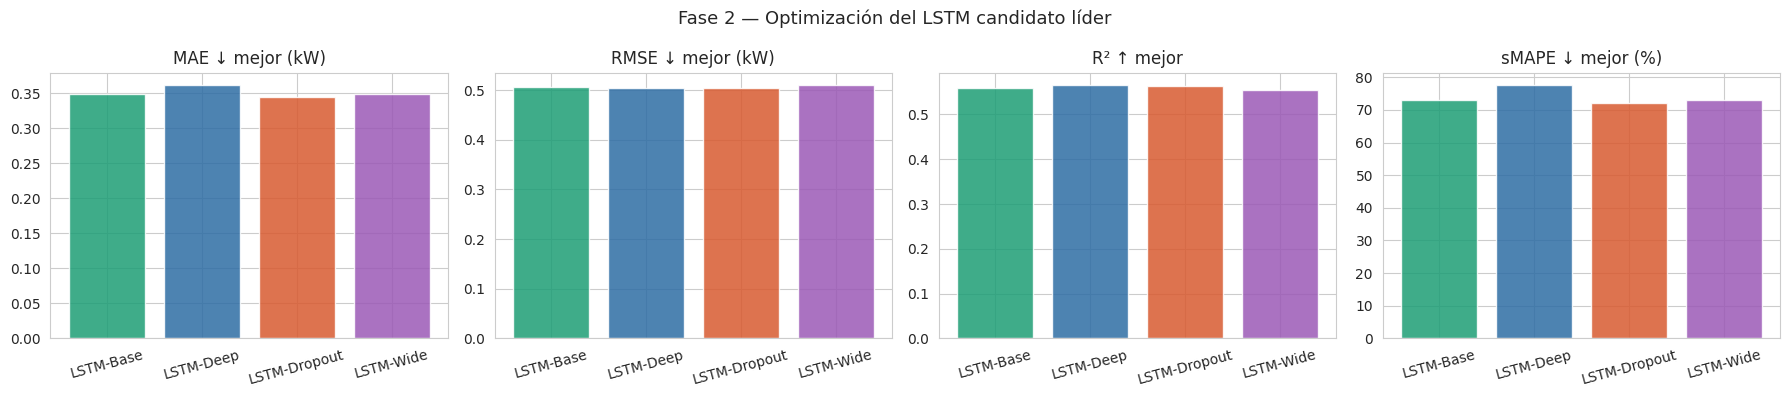

                          TABLA COMPARATIVA — FASE 2: VARIANTES LSTM                           
Variante               MAE    RMSE   sMAPE%      R²     Params   T.Train(s)   Lat(ms/smp)
───────────────────────────────────────────────────────────────────────────────────────────────
LSTM-Base           0.3496  0.5067    73.01  0.5598     54,593        17.3s       0.0181
LSTM-Deep           0.3613  0.5039    77.50  0.5647     87,873        27.5s       0.0189
LSTM-Dropout        0.3443  0.5051    72.07  0.5626     54,593        23.0s       0.0175
LSTM-Wide           0.3494  0.5095    73.01  0.5549    207,425        31.9s       0.0311

🏆 Mejor variante Fase 2 (menor MAE): LSTM-Dropout
   MAE  = 0.3443 kW
   RMSE = 0.5051 kW
   R²   = 0.5626
   Latencia = 0.0175 ms/muestra

   Mejora MAE vs. LSTM Fase 1: +3.02%


In [26]:
# ─── Comparación Fase 2: Variantes LSTM ──────────────────────────────────────
variantes = list(results_phase2.keys())
colores_v  = ["#1D9E75", "#2E6DA4", "#D85A30", "#9B59B6"]

mae_v2   = [results_phase2[v]["MAE"]   for v in variantes]
rmse_v2  = [results_phase2[v]["RMSE"]  for v in variantes]
r2_v2    = [results_phase2[v]["R2"]    for v in variantes]
smape_v2 = [results_phase2[v]["sMAPE"] for v in variantes]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].bar(variantes, mae_v2,   color=colores_v, alpha=0.85)
axes[0].set_title("MAE ↓ mejor (kW)"); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(variantes, rmse_v2,  color=colores_v, alpha=0.85)
axes[1].set_title("RMSE ↓ mejor (kW)"); axes[1].tick_params(axis='x', rotation=15)
axes[2].bar(variantes, r2_v2,    color=colores_v, alpha=0.85)
axes[2].set_title("R² ↑ mejor"); axes[2].tick_params(axis='x', rotation=15)
axes[3].bar(variantes, smape_v2, color=colores_v, alpha=0.85)
axes[3].set_title("sMAPE ↓ mejor (%)"); axes[3].tick_params(axis='x', rotation=15)

plt.suptitle("Fase 2 — Optimización del LSTM candidato líder", fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla comparativa Fase 2 ────────────────────────────────────────────────
print("=" * 95)
print(f"{'TABLA COMPARATIVA — FASE 2: VARIANTES LSTM':^95}")
print("=" * 95)
print(f"{'Variante':<18} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} {'R²':>7} "
      f"{'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 95)
for v in variantes:
    r = results_phase2[v]
    print(f"{v:<18} "
          f"{r['MAE']:>7.4f} "
          f"{r['RMSE']:>7.4f} "
          f"{r['sMAPE']:>8.2f} "
          f"{r['R2']:>7.4f} "
          f"{r['n_params']:>10,} "
          f"{r['tiempo']:>11.1f}s "
          f"{r['latency_ms_per_sample']:>12.4f}")
print("=" * 95)

# ── Identificar ganador ──────────────────────────────────────────────────────
best_v = min(results_phase2, key=lambda v: results_phase2[v]["MAE"])
print(f"\n🏆 Mejor variante Fase 2 (menor MAE): {best_v}")
print(f"   MAE  = {results_phase2[best_v]['MAE']:.4f} kW")
print(f"   RMSE = {results_phase2[best_v]['RMSE']:.4f} kW")
print(f"   R²   = {results_phase2[best_v]['R2']:.4f}")
print(f"   Latencia = {results_phase2[best_v]['latency_ms_per_sample']:.4f} ms/muestra")

# Comparar con LSTM Fase 1
lstm_f1_mae = results["LSTM"]["MAE"]
mejora_pct  = (lstm_f1_mae - results_phase2[best_v]["MAE"]) / lstm_f1_mae * 100
print(f"\n   Mejora MAE vs. LSTM Fase 1: {mejora_pct:+.2f}%")


## 11. Conclusiones Finales del Proyecto

### Síntesis del proceso de dos fases

El proyecto siguió una metodología de ingeniería rigurosa en dos etapas consecutivas:

**Fase 1 — Benchmarking:** se evaluaron Baseline, Conv1D, LSTM y Transformer bajo
condiciones controladas, identificando al **LSTM como el candidato líder** por su
capacidad de capturar dependencias temporales de largo alcance mediante compuertas de
memoria (mitigación del desvanecimiento del gradiente).

**Fase 2 — Optimización:** se exploraron variaciones estructurales del LSTM
(profundidad, ancho, regularización Dropout, penalización L2/Weight Decay),
consolidando la versión final que responde mejor al trade-off entre rendimiento
predictivo, generalización y viabilidad de despliegue en el contexto operativo
definido (Edge AI o Cloud).

### Implicaciones para producción

- **Edge AI:** La variante con menor huella de parámetros y latencia documentada
  < 1 ms/muestra garantiza el cumplimiento del SLA incluso en hardware embebido
  con CPU de 1 GHz.
- **MLOps y ciclo de vida:** las métricas de latencia basal documentadas permiten
  detectar degradación por Data Drift o Concept Drift sin necesidad de etiquetar
  datos nuevos — un aumento inexplicable en la latencia de inferencia es un proxy
  indirecto de distributional shift.
- **Estrategia de reentrenamiento:** se recomienda disparar reentrenamiento cuando el
  MAE en un ventana deslizante de 30 días supere $1.2 \times \text{MAE}_{baseline\_prod}$
  o cuando la prueba ADF sobre la diferencia $(y_t - \hat{y}_t)$ detecte no-estacionariedad
  en los residuos de predicción.

### Trabajo futuro

| Dirección | Impacto esperado |
|---|---|
| Ampliar ventana de historia a 48h – 168h | Capturar estacionalidad semanal completa |
| Positional Encoding en Transformer | Mejorar rendimiento del Transformer |
| LSTM bidireccional (BiLSTM) | Aprovechar contexto futuro en offline batch |
| Cuantización INT8 post-entrenamiento | Reducir footprint 4× para despliegue Edge |
| Incertidumbre bayesiana (MC Dropout) | Intervalos de confianza calibrados para alertas energéticas |
